# Task 1.1: Sampling Theorem

**Student Name:**  Haris Salii
**Country:**  Switzerland
**Semester term:**  HS26  


## Day 1: Data & Domain

### Use Case
*Focus: domain and application context*

<span style="background-color: #eeeeee;">*Guidelines: Describe a realistic and application scenario in which the targeted signal or image processing task plays a critical role. Clearly specify the domain, the system in which the signal or image is measured or processed, and the practical objective of this system. Explain who relies on the signal or image and for what type of decision-making or analysis. Briefly explain why this use case is particularly relevant for your selected country. Justify your choice based on economic, environmental, societal, technological, or geographic factors. Write your use case as a short, focused paragraph (1-3 sentences).*</span>

> In the context of monitoring local solar energy potential, continuous-time signals generated by variations in incoming solar radiation are acquired and converted into digital form using a pyranometer and the automatic data acquisition system at the MeteoSwiss station Bern/Zollikofen in order to record solar irradiance as 10-minute mean values.  
> The resulting digital signals are analyzed by energy planners and photovoltaic system operators to assess solar energy availability and determine whether the sampling interval captures relevant short-term variations.  
> This use case is particularly relevant for Switzerland because solar irradiance varies with cloud cover, season, and location, which can affect the planning and operation of photovoltaic systems.

### Problem Statement
*Focus: technical vulnerability*

<span style="background-color: #eeeeee;">*Guidelines: Formulate a clear and technically precise problem statement. Explicitly refer to the signal or image processing task under investigation and identify the specific technical risk or limitation associated with it. Describe what may go wrong if an approach, method, or parameter is chosen or applied inadequately. Explain why this technical vulnerability is critical within your selected use case. Write your problem statement as a short, focused paragraph (1–3 sentences).*</span>

> This project addresses the problem of determining an appropriate sampling rate for solar irradiance signals within the context of monitoring local solar energy potential at the MeteoSwiss station Bern/Zollikofen in Switzerland. If the sampling rate is too low, aliasing and the loss of short-term irradiance variations may occur, leading to an inaccurate representation of the available solar energy. If the sampling rate is unnecessarily high, the resulting data volume increases storage and processing requirements without necessarily providing additional useful information.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

<span style="background-color: #eeeeee;">*Guidelines: Clearly state what you intend to understand or demonstrate in relation to your use case. Formulate your objective at a conceptual level without describing specific methods, algorithms, or implementation details. The objective should explain what aspect of signal or image behavior you aim to analyze and why this analysis is important for your application. Write your objective as a short, focused paragraph (1–2 sentences).*</span>

> The objective of this project is to investigate how the choice of sampling interval affects the monitoring of short-term changes in solar irradiance at the MeteoSwiss station Bern/Zollikofen. The goal is to understand when the measured signal still provides enough information for a reliable assessment of local solar energy availability.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

<span style="background-color: #eeeeee;">*Guidelines: Describe a representative one-dimensional signal or two-dimensional image suitable for your use case. Briefly explain its physical origin, how it is acquired, its unit of measurement, and the key characteristics relevant to your investigation. Specify the exact dataset name and repository or institution from which the data originate, and justify why this source is appropriate. Write 3-5 concise sentences.*</span>

> The selected one-dimensional signal represents global solar irradiance at the MeteoSwiss station Bern/Zollikofen. It is generated by incoming direct and diffuse solar radiation, measured using a radiation sensor, and expressed in watts per square metre (W/m²). The dataset contains 10-minute mean values for the complete year 2025 and captures daily, seasonal, and short-term variations caused by changing weather conditions. The data originate from the “Automatic Weather Stations Measurement Values” dataset provided by MeteoSwiss and are appropriate because they offer regularly sampled measurements from an official Swiss monitoring station.

<span style="background-color: #eeeeee;">*Guideline: Visualize a representative excerpt of your signal or a relevant region of your image. If the data are audio-based, additionally provide a playable audio segment. All visualizations must include clearly labeled axes and the correct units.*</span>

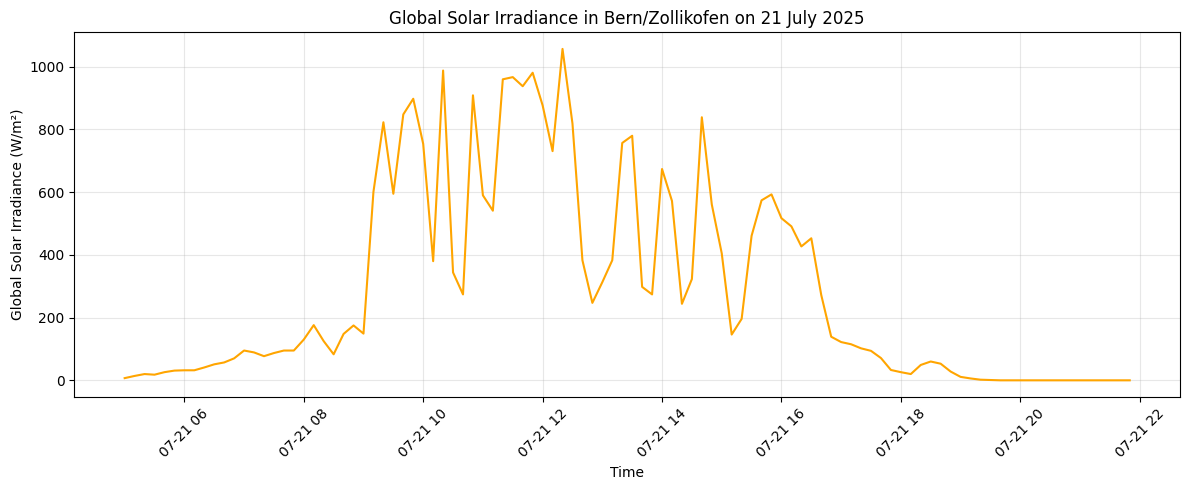

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/solarstrahlung_bern_2025.csv",
    sep=";"
)

data["time"] = pd.to_datetime(
    data["reference_timestamp"],
    dayfirst=True
)

selected_day = data[
    data["time"].dt.date == pd.Timestamp("2025-07-21").date()
]

selected_day = selected_day[
    selected_day["time"].dt.hour.between(5, 21)
]

plt.figure(figsize=(12, 5))
plt.plot(
    selected_day["time"],
    selected_day["gre000z0"],
    color="orange"
)

plt.title("Global Solar Irradiance in Bern/Zollikofen on 21 July 2025")
plt.xlabel("Time")
plt.ylabel("Global Solar Irradiance (W/m²)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations**:
The global solar irradiance increases from approximately 10 W/m² at 05:00 to more than 800 W/m² after 09:00. Between approximately 09:00 and 15:30, the signal shows several strong fluctuations and reaches a maximum of about 1,057 W/m² around midday. After 16:30, the measured irradiance decreases and approaches 0 W/m² after approximately 20:00.

**Interpretation of Nyquist Frequency and Nyquist Rate**

The available signal contains one 10-minute mean value every 10 minutes, corresponding to a sampling rate of six measurements per hour. The resulting Nyquist frequency is three cycles per hour, which corresponds to a shortest theoretical period of 20 minutes. Variations occurring faster than this limit cannot be represented reliably and may be averaged, missed, or affected by aliasing. In practice, an unnecessarily low sampling rate may hide relevant irradiance changes, while a very high sampling rate increases data volume and processing requirements.

## Day 2: Methodological Design

<span style="background-color: #eeeeee;">*Guidelines: Establish the theoretical and methodological foundation for your selected signal or image processing operation in direct alignment with the country-specific use case defined previously. Formally state the relevant theoretical principle and explain its assumptions, validity conditions, and domain-specific applicability. Select and justify concrete methods and parameter values appropriate for your one-dimensional signal or two-dimensional image data, explaining why these choices fit the defined analytical objective.
Derive necessary quantities mathematically where applicable, documenting each step with explicit assumptions and consistent units (temporal, spatial, or frequency units as relevant). Specify and justify the experimental design to be executed on the next day: define the parameters to vary, the control/baseline configuration, and the structured parameter sweep (ranges and step sizes). Theoretically predict the expected qualitative effects of these variations on the signal or image and identify likely failure modes (e.g., aliasing, instability, sensitivity to noise, loss of detail). Discuss methodological limitations, idealizations, and potential sources of misinterpretation. No simulations, visualizations, or experimental demonstrations should be included.*
</span>

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

<span style="background-color: #eeeeee;">*Guidelines: Establish the governing theoretical principle underlying your selected signal or image processing operation and briefly justify your chosen 1-2 method(s) in direct relation to your previously defined country-specific use case. State the key assumptions and validity conditions of the theory, and explain why the selected method appropriately operationalizes this principle for your data characteristics and analytical objective. Keep the explanation concise and technically precise. 2-4 sentences.*</span>

You may use the following structure as guidance:

> In dieser Untersuchung wird das Nyquist-Shannon-Abtasttheorem angewendet, um zu untersuchen, wie unterschiedliche Messintervalle die Erfassung von Solarstrahlungsschwankungen an der MeteoSwiss-Station Bern/Zollikofen beeinflussen. 

> Das Theorem setzt ein bandbegrenztes kontinuierliches Signal und eine gleichmässige Abtastung voraus. Für eine ideale Rekonstruktion muss die Abtastfrequenz mehr als doppelt so hoch sein wie die höchste enthaltene Signalfrequenz.

> Als Referenz wird eine kontrollierte, bandbegrenzte Approximation auf Grundlage der vorhandenen MeteoSwiss-Daten gewählt, da die ursprünglichen Messwerte bereits zehnminütige Mittelwerte darstellen.

> Bei einer zu niedrigen Abtastfrequenz kann Aliasing auftreten, wodurch schnelle Veränderungen der Solarstrahlung fälschlicherweise als langsamere Schwankungen erscheinen und relevante Informationen verloren gehen.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

<span style="background-color: #eeeeee;">*Guidelines: Define and justify relevant signal/image parameters and method-specific parameters required for your analysis. Clearly distinguish between data-inherent parameters (e.g., sampling frequency, spatial resolution, signal length, bandwidth) and method parameters (e.g., kernel size, lag range, cutoff frequency, window length). Derive necessary quantities mathematically where applicable and document each step with explicit assumptions and consistent physical units. Explicitly map abstract parameters to their physical meaning in your domain (e.g., lag in days, kernel width in meters or pixels). Parameter choices must be technically motivated and aligned with the defined use case. 2-4 sentences.*</span>

**Mathematische Herleitung**

Die ursprüngliche Abtastrate der MeteoSwiss-Daten beträgt:

$$
f_{s,\mathrm{original}} = \frac{60}{10} = 6\,\text{Messwerte/h}
$$

Daraus ergibt sich die Nyquist-Frequenz der vorhandenen Messreihe:

$$
f_{N,\mathrm{original}} = \frac{6}{2} = 3\,\text{Zyklen/h}
$$

Für die gewählte Modellbandbreite von 2 Zyklen pro Stunde ergibt sich folgende theoretische Nyquist-Rate:

$$
f_{s,\mathrm{Nyquist}} = 2 \cdot B_{\mathrm{model}} = 2 \cdot 2 = 4\,\text{Messwerte/h}
$$

Dies entspricht einem Messintervall von 15 Minuten. Für die ideale Rekonstruktion verwenden wir eine Abtastrate oberhalb dieser Grenze.

> Die MeteoSwiss-Messreihe der Station Bern/Zollikofen enthält zehnminütige Mittelwerte der Globalstrahlung in W/m². Daraus ergeben sich eine ursprüngliche Abtastrate von 6 Messwerten pro Stunde und eine Nyquist-Frequenz von 3 Zyklen pro Stunde.

> Für das experimentelle Referenzmodell wird eine Bandbreite von 2 Zyklen pro Stunde festgelegt, was einer kürzesten vollständigen Schwingungsperiode von 30 Minuten entspricht. Dieser Wert ist eine bewusst gewählte Modellannahme unterhalb der Nyquist-Frequenz der vorhandenen Messreihe und keine nachgewiesene physikalische Grenze der tatsächlichen Solarstrahlung.

> Die daraus abgeleitete Nyquist-Rate beträgt 4 Messwerte pro Stunde. Diese Parameter ermöglichen einen strukturierten Vergleich verschiedener Messintervalle, um den möglichen Verlust kurzfristiger Einstrahlungsschwankungen zu untersuchen.

### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*

<span style="background-color: #eeeeee;">*Guidelines: Specify the experimental setup to be implemented on the next days. Define the baseline configuration and identify the key 2-4 parameters that will be systematically varied. Describe the structured parameter sweep (ranges, step sizes, and controlled variables) and justify why these variations are meaningful for your signal or image and use case. Theoretically predict the expected qualitative effects of parameter changes. Ensure the setup is traceable and reproducible by clearly documenting fixed settings and variation logic. Theoretically predict the expected qualitative effects of these parameter changes on signal behavior, image structure, or system response. No simulations or results should be included. 2-4 sentences.*</span>

You may use the following structure as guidance:

> Als Ausgangskonfiguration dient eine hochauflösende, bandbegrenzte Approximation des ausgewählten MeteoSwiss-Tagesverlaufs vom 21. Juli 2025 mit einer Modellbandbreite von 2 Zyklen pro Stunde; die ursprüngliche zehnminütige Abtastung wird als Vergleichskonfiguration verwendet.

> Die Abtastrate wird systematisch durch drei Messintervalle variiert: 10 Minuten (6 Messwerte/h), 15 Minuten (4 Messwerte/h) und 30 Minuten (2 Messwerte/h), um die Bedingungen oberhalb, genau an und unterhalb der Nyquist-Rate abzudecken.

> Der Untersuchungszeitraum, das Referenzsignal, die Modellbandbreite und die zeitliche Ausrichtung bleiben dabei unverändert, sodass Unterschiede auf die gewählte Abtastrate zurückgeführt werden können.

> Theoretisch wird erwartet, dass die Signalanteile oberhalb der Nyquist-Grenze ausreichend erfasst werden, während am Grenzwert phasenabhängige Rekonstruktionsprobleme und bei zu geringer Abtastrate Aliasing beziehungsweise Informationsverlust auftreten können.

### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

<span style="background-color: #eeeeee;">*Guidelines: Identify the main methodological 1-3 limitations of your theoretical model, method selection, and parameterization. Explicitly state idealized assumptions and discuss how real-world signal or image characteristics may violate them (e.g., noise, non-linearity, non-stationarity, boundary effects, model mismatch, limited resolution). Analyze under which conditions the method remains stable and valid, and under which conditions it may become unreliable or misleading in your use case. 1-3 sentences.*</span>

You may use the following structure as guidance:

> Das Nyquist-Shannon-Abtasttheorem setzt ein bandbegrenztes Signal und eine gleichmässige Abtastung voraus; bei den realen MeteoSwiss-Daten können jedoch schnelle Einstrahlungsschwankungen durch die zehnminütige Mittelwertbildung bereits abgeschwächt oder verloren gegangen sein.

> Die festgelegte Modellbandbreite von 2 Zyklen pro Stunde stellt deshalb eine experimentelle Annahme dar, während die tatsächliche physikalische Bandbreite der Solarstrahlung unbekannt bleibt.

> Die Untersuchung erlaubt unter kontrollierten Modellbedingungen einen nachvollziehbaren Vergleich verschiedener Abtastraten, ihre Ergebnisse dürfen jedoch aufgrund möglicher schneller Wolkenwechsel, Messrauschen und Modellabweichungen nicht als exakte Rekonstruktion der ursprünglichen Solarstrahlung interpretiert werden.

## Day 3: Implementation

*Focus: structured, traceable execution*

<span style="background-color: #eeeeee;">*Guidelines: Implement the previously defined methodological framework in a structured and reproducible manner. Organize your notebook clearly, separating data preparation, parameter definition, baseline configuration, and parameter variation. The implementation must directly follow the previously defined methodological plan. All relevant parameters must be explicitly declared and applied as specified. Do not introduce new methods or undocumented parameter changes; any deviation must be briefly justified (one sentence).
Ensure that each experiment is traceable by clearly labeling configurations and avoiding undocumented changes. Visualizations must include properly labeled axes (with units where applicable), clear legends, and consistent formatting to allow comparison across parameter settings.
 If not otherwise stated, libarys may be used for your implementations. Keep experiments concise and focused. Observations, interpretation and performance evaluation will be conducted on a later day.*</span>

<span style="background-color: #eeeeee;">*Code Quality Requirements: The submission must not contain any commented-out code passages. Code should be clean, readable, and executable without residual development artifacts. Comments should be used sparingly and only where they add value. In particular, comments are appropriate when explaining why a specific methodological decision was made, clarifying non-obvious implementation details, or referencing a theoretical source. Avoid redundant comments that merely restate what the code already expresses.
The code should be written in a clear and structured manner such that its logic is largely self-explanatory. Use meaningful variable names and consistent formatting to enhance readability.*</span>

## Day 4: Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

<span style="background-color: #eeeeee;">*Systematically evaluate the predefined experiment design in relation to the defined use case. The evaluation must be traceable, structured, and based on consistent criteria. All reported metrics or extracted quantities must include appropriate physical units or clearly indicate normalization to ensure consistent and meaningful comparison. The same predefined evaluation approach must be applied consistently across all experiments and parameter configurations to maintain traceability and comparability. No new simulations, theoretical derivations, or interpretative discussion should be introduced.*</span>

### Evaluation Approach Definition

<span style="background-color: #eeeeee;">*Guidelines: Define 1–2 quantitative evaluation approaches, which may consist of numerical metrics and/or quantitatively interpretable visualizations. Justify why the selected approach is appropriate for your signal or image characteristics and application objective, and clearly specify what aspect of performance it captures (e.g., fidelity, detection accuracy, reconstruction quality, robustness, distortion). Visualizations must include labeled axes with units and enable measurable comparison across configurations. 2-3 sentences.*</span>

You may use the following structures as guidance, depending on whether your evaluation approach is metric-based or visualization-based.

#### Template – Metric-Based Evaluation

> The selected metric is __________, which quantifies ____________ in relation to [the defined use case].
It is specifically chosen because the problem statement requires accurate assessment of ____________, and this metric directly reflects changes in ____________.
The validity of this metric depends on ____________, which must hold for the evaluation to be meaningful in this application.

Example – Root Mean Squared Error (RMSE):

> The selected metric is RMSE, which quantifies the deviation between the reconstructed signal and the high-resolution reference. It is specifically chosen because [the use case] requires accurate amplitude reconstruction over time, and RMSE directly reflects reconstruction fidelity. The metric is meaningful here because a validated reference signal is available and serves as ground truth.

#### Template – Visualization-Based Evaluation

> The evaluation uses a __________ visualization, representing ____________ with clearly labeled axes and units.
The evaluated quantity is ____________, which is directly relevant to [the defined use case] because the problem requires reliable assessment of ____________.
This approach is appropriate under ____________, ensuring that the extracted feature meaningfully reflects performance in this application context.

Example – Frequency Spectrum Comparison:

> The evaluation uses a frequency spectrum visualization to assess whether dominant periodic components are preserved. The evaluated quantity is the measurable peak frequency and its amplitude, which are directly relevant because the use case requires reliable detection of periodic behavior. This approach is appropriate since frequency preservation is more critical than pointwise amplitude accuracy in this application.

### Evaluation Comparison Execution

<span style="background-color: #eeeeee;">*Guidelines: Apply the defined evaluation approach consistently across all predefined experiments or configurations. Systematically vary 2–4 previously defined key parameters and quantify their influence on performance relative to a clearly specified baseline configuration. Results must be reported in a structured format (e.g., tables or measurable graphics) to ensure traceability. 2-4 sentences.*</span>


#### Template – Parameter Evaluation (Metric-Based)

>The influence of key parameters __________ was evaluated using the previously defined metric __________.
These parameters are essential for [the defined use case] because they directly affect ____________, which is critical for ____________.
Changes in __________ [metric] across parameter settings quantify how sensitive the experiment design is to ____________.
Relative performance change was computed with respect to the baseline configuration ____________.

#### Template – Parameter Evaluation (Visualization-Based)

>The influence of key parameters __________ was evaluated using the previously defined visualization-based measure __________.
These parameters are essential for the defined use case because they influence ____________, which determines ____________ in [the application context].
Differences in the extracted quantity __________ across parameter settings quantify the impact of ____________ on performance.
Relative performance change was computed with respect to the baseline configuration ____________.

In [ ]:
## Placeholder for code-based analysis, quantitative result reporting, and structured comparison using tables and/or graphics.

Example universal comparison table:

| Experiment / Configuration        | Metric / Quantity 1 | Metric / Quantity 2 (optional) | Relative Change to Baseline (%) |
|:----------------------------------|:--------------------|:--------------------------------|:--------------------------------|
| Baseline: ____________            |                     |                                  | 0%                               |
| Configuration 1: ____________     |                     |                                  |                                  |
| Configuration 2: ____________     |                     |                                  |                                  |
| Configuration 3: ____________     |                     |                                  |                                  |


Example for Sampling Rate Variation:


| Experiment / Configuration | RMSE | Relative Change to Baseline (%) |
|:----------------------------|:-----|:--------------------------------|
| Baseline: Fs = 100 Hz      | 0.12 | 0%                               |
| Fs = 50 Hz                 | 0.18 | +50%                             |
| Fs = 25 Hz                 | 0.45 | +275%                            |

## Day 5: Analysis & Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image. Structure your analysis into (1) observations, (2) interpretation, and (3) discussion. Observations must reference concrete quantitative results; interpretations must explain domain-specific implications; the discussion must critically assess the practical applicability, limitations, and risks of your implementation and evaluation approach. All arguments must explicitly connect to the original problem statement and use case. No new simulations or derivations may be introduced.*</span>

### Observations (3-5 sentences)
Focus: Describe measurable results only — no explanation.

> The quantitative evaluation shows that ____________ changes from ____________ to ____________ across configurations ____________.
The defined metric / extracted quantity indicates that ____________.
Performance differences are most pronounced when ____________.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.

>In the context of ____________ [use case], these results imply that ____________.
The observed variation in ____________ affects ____________ because ____________.
This suggests that ____________ is particularly critical for achieving the objective defined in the problem statement.


### Discussion and Critical Reflection (4–6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*

> For the defined use case, the configurations ____________ performed well because they achieved ____________, which aligns with the requirement of ____________.
In contrast, configurations ____________ showed reduced performance, leading to ____________ and limiting their suitability for this application.
The achieved performance level can be considered sufficient / insufficient for the use case because ____________.
The implementation and evaluation approach assumes ____________, which may be constrained under real-world conditions such as ____________.
To improve robustness or applicability, future work should address ____________ or refine ____________.

## Day 15 

### Final Reflections on MC
>Overall, the most successful aspect of MC1 was ____________, particularly in relation to ____________ within the defined use case. The implementation of ____________ worked well because ____________, leading to ____________.
If repeating this work, I would reconsider ____________ or refine ____________, as this could improve ____________ and reduce ____________. Certain challenges emerged during ____________, highlighting the importance of ____________ in practical signal/image analysis.
I was particularly impressed by ____________, especially how ____________ influenced ____________ in the context of the application.
Through this project, I learned that ____________, and I developed a clearer understanding of ____________, especially regarding the connection between theoretical principles and real-world constraints.

### Revisions
<span style="background-color: #fff3b0;"><strong>Template for Revisions:</strong> [your changes... ]</span>

### Sources and Tools

- Data source: MeteoSwiss, “Automatic Weather Stations Measurement Values,” parameter `gre000z0`, station Bern/Zollikofen.  
  https://opendatadocs.meteoswiss.ch/de/a-data-groundbased/a1-automatic-weather-stations
- Tools: Python 3, pandas, and Matplotlib.
- The Python code and English wording were developed with assistance from OpenAI ChatGPT/Codex and reviewed and adapted by the author.